In [38]:
import os
import sys
import copy
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn

In [2]:
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("__file__"), "..")))


In [58]:
%reload_ext autoreload
%autoreload 2
from core.data import fetch_ohlcv_data
from core.stats import CAGR, volatility, Sharpe, max_dd, Sortino, calamar, jensens_alpha, rolling_sharpe, rolling_alpha

List of all the stocks I want to have in my tradable universe for backtesting

In [22]:
nifty_top_20 = [
    "RELIANCE.NS", "HDFCBANK.NS", "ICICIBANK.NS", "INFY.NS", "AXISBANK.NS", 
    "TCS.NS", "LT.NS", "BHARTIARTL.NS", "SBIN.NS", "ITC.NS", 
    "HINDUNILVR.NS", "BAJFINANCE.NS", "KOTAKBANK.NS", "MARUTI.NS", "M&M.NS", 
    "TATASTEEL.NS", "SUNPHARMA.NS", "HCLTECH.NS", "ADANIENT.NS", "NTPC.NS"
]

# PORTFOLIO REBALANCING

In [6]:
ohlcv_data = fetch_ohlcv_data(nifty_top_20, 3650, "1mo")

Successfully downloaded 20/20 stocks.


In [7]:
def get_monthly_return(ohlcv_data):
    """
    Calculate monthly returns for the given stocks.
    
    Parameters:
    mid_cap_dict (dictionary): Dictionary of stock symbols.
    
    Returns:
    pd.DataFrame: DataFrame containing monthly returns for each stock.
    """
    ohlcv_dict = copy.deepcopy(ohlcv_data)
    return_df = pd.DataFrame()
    for stock in nifty_top_20:
        print("calculated monthly return for ", stock)
        ohlcv_dict[stock]["mon_ret"] = ohlcv_dict[stock]["Close"].pct_change()
        return_df[stock] = ohlcv_dict[stock]["mon_ret"]
    return_df.dropna(inplace=True)
    return return_df

In [8]:
return_df = get_monthly_return(ohlcv_data)

calculated monthly return for  RELIANCE.NS
calculated monthly return for  HDFCBANK.NS
calculated monthly return for  ICICIBANK.NS
calculated monthly return for  INFY.NS
calculated monthly return for  AXISBANK.NS
calculated monthly return for  TCS.NS
calculated monthly return for  LT.NS
calculated monthly return for  BHARTIARTL.NS
calculated monthly return for  SBIN.NS
calculated monthly return for  ITC.NS
calculated monthly return for  HINDUNILVR.NS
calculated monthly return for  BAJFINANCE.NS
calculated monthly return for  KOTAKBANK.NS
calculated monthly return for  MARUTI.NS
calculated monthly return for  M&M.NS
calculated monthly return for  TATASTEEL.NS
calculated monthly return for  SUNPHARMA.NS
calculated monthly return for  HCLTECH.NS
calculated monthly return for  ADANIENT.NS
calculated monthly return for  NTPC.NS


In [9]:
def portfolio_rebalance(return_df, keep, throw):
    """
    Rebalance the portfolio based on monthly returns.
    
    Parameters:
    return_df (pd.DataFrame): DataFrame containing monthly returns for each stock.
    keep (int): Number of stocks to keep in the portfolio.
    throw (int): Number of stocks to throw out of the portfolio.
    initial_investment (float): Initial investment amount (default is 1,000,000).
    
    Returns:
    pd.DataFrame: DataFrame containing portfolio value over time.
    """
    df = return_df.copy()
    portfolio = []
    monthly_return = []
    for i in range (len(df)):
        if len(portfolio) > 0:
            monthly_return.append(df[portfolio].iloc[i, :].mean())
            bad_stocks = df[portfolio].iloc[i,:].sort_values(ascending=True)[:throw].index.values.tolist()
            portfolio = [t for t in portfolio if t not in bad_stocks]
        else:
            monthly_return.append(0)
            print("No stocks in portfolio")
        fill = keep - len(portfolio)
        new_picks = df.iloc[i,:].sort_values(ascending=False)[:fill].index.values.tolist()
        portfolio = portfolio + new_picks
        print(portfolio)
    monthly_ret_df = pd.DataFrame(np.array(monthly_return),columns=["mon_ret"])
    return monthly_ret_df

In [10]:
new_portfolio = portfolio_rebalance(return_df, 6, 3)

No stocks in portfolio
['LT.NS', 'BAJFINANCE.NS', 'MARUTI.NS', 'AXISBANK.NS', 'SBIN.NS', 'ITC.NS']
['BAJFINANCE.NS', 'SBIN.NS', 'ITC.NS', 'ADANIENT.NS', 'NTPC.NS', 'M&M.NS']
['BAJFINANCE.NS', 'SBIN.NS', 'ITC.NS', 'BAJFINANCE.NS', 'MARUTI.NS', 'ICICIBANK.NS']
['BAJFINANCE.NS', 'SBIN.NS', 'BAJFINANCE.NS', 'AXISBANK.NS', 'SBIN.NS', 'TATASTEEL.NS']
['SBIN.NS', 'SBIN.NS', 'TATASTEEL.NS', 'MARUTI.NS', 'HCLTECH.NS', 'RELIANCE.NS']
['TATASTEEL.NS', 'MARUTI.NS', 'ICICIBANK.NS', 'TATASTEEL.NS', 'MARUTI.NS', 'KOTAKBANK.NS']
['TATASTEEL.NS', 'ICICIBANK.NS', 'TATASTEEL.NS', 'NTPC.NS', 'HCLTECH.NS', 'TATASTEEL.NS']
['ICICIBANK.NS', 'NTPC.NS', 'HCLTECH.NS', 'ADANIENT.NS', 'RELIANCE.NS', 'ITC.NS']
['ICICIBANK.NS', 'ADANIENT.NS', 'ITC.NS', 'BAJFINANCE.NS', 'TATASTEEL.NS', 'BHARTIARTL.NS']
['ADANIENT.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS', 'RELIANCE.NS', 'ADANIENT.NS', 'TCS.NS']
['ADANIENT.NS', 'RELIANCE.NS', 'ADANIENT.NS', 'ADANIENT.NS', 'SBIN.NS', 'KOTAKBANK.NS']
['RELIANCE.NS', 'KOTAKBANK.NS', 'LT.NS'

In [56]:
cagr = CAGR(new_portfolio, 12, "mon_ret", False)  # Calculate CAGR
vol = volatility(new_portfolio, 12, "mon_ret", False)  # Calculate Volatility
sharpe = Sharpe(new_portfolio, 12, "mon_ret", False)  # Calculate Sharpe Ratio
mdd = max_dd(new_portfolio, "mon_ret", False) # Calculate max drawdown
rolling_sharpe_df = rolling_sharpe(new_portfolio, 12, 3, "mon_ret", False)

# 4. Display Results
print(f"--- Statistics for your portfolio (Last 10 Years) ---")
print(f"CAGR:           {cagr:.2%}")
print(f"volatility:     {vol:.2%}")
print(f"Sharpe Ratio:   {sharpe:.2f}")
print(f"Max Drawdown:   {mdd:.2%}")
rolling_sharpe_df['rolling_sharpe']


--- Statistics for your portfolio (Last 10 Years) ---
CAGR:           19.32%
volatility:     18.76%
Sharpe Ratio:   0.66
Max Drawdown:   40.83%


0            NaN
1            NaN
2       3.182653
3      18.292749
4       1.493801
         ...    
114     3.465268
115     1.222178
116     0.163332
117     0.017779
118    -1.428896
Name: rolling_sharpe, Length: 119, dtype: float64

In [31]:
# 1. Download Data
ticker ="^NSEI"
data = yf.download(ticker, period="10y", interval="1mo")

# 2. Clean Data (yfinance multi-index handling if necessary)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# 3. Calculate KPIs
# Since we are using daily data, timeframe = 252
# Since we downloaded ohlcv, is_price = True
cagr_val = CAGR(data, timeframe=12, column='Close', is_price=True)
vol_val = volatility(data, timeframe=12, column='Close', is_price=True)
sharpe_val = Sharpe(data, timeframe=12, column='Close', is_price=True)
mdd_val = max_dd(data, column='Close', is_price=True)
rol_sh = rolling_sharpe(data, timeframe=12, window=3, column='Close', is_price=True)

# 4. Display Results
print(f"--- Statistics for {ticker} (Last 10 Years) ---")
print(f"CAGR:           {cagr_val:.2%}")
print(f"volatility:     {vol_val:.2%}")
print(f"Sharpe Ratio:   {sharpe_val:.2f}")
print(f"Max Drawdown:   {mdd_val:.2%}")
rol_sh

[*********************100%***********************]  1 of 1 completed

--- Statistics for ^NSEI (Last 10 Years) ---
CAGR:           11.31%
volatility:     15.95%
Sharpe Ratio:   0.27
Max Drawdown:   29.34%


Price,Close,High,Low,Open,Volume,return,rolling_sharpe
Date,,,,,,,
2016-04-01,7849.799805,7992.000000,7516.850098,7718.049805,3538800,NaN,NaN
2016-05-01,8160.100098,8213.599609,7678.350098,7822.700195,4361300,0.039530,NaN
2016-06-01,8287.750000,8308.150391,7927.049805,8179.200195,4193500,0.015643,NaN
2016-07-01,8638.500000,8674.700195,8287.549805,8313.049805,3321700,0.042321,6.299324
2016-08-01,8786.200195,8819.200195,8518.150391,8654.299805,3826100,0.017098,4.431040
...,...,...,...,...,...,...,...
2025-11-01,26202.949219,26310.449219,25318.449219,25696.849609,5495100,0.018694,3.221651
2025-12-01,26129.599609,26325.800781,25693.250000,26325.800781,5369800,-0.002799,2.093505
2026-01-01,25320.650391,26373.199219,24919.800781,26173.300781,8376000,-0.030959,-1.510061


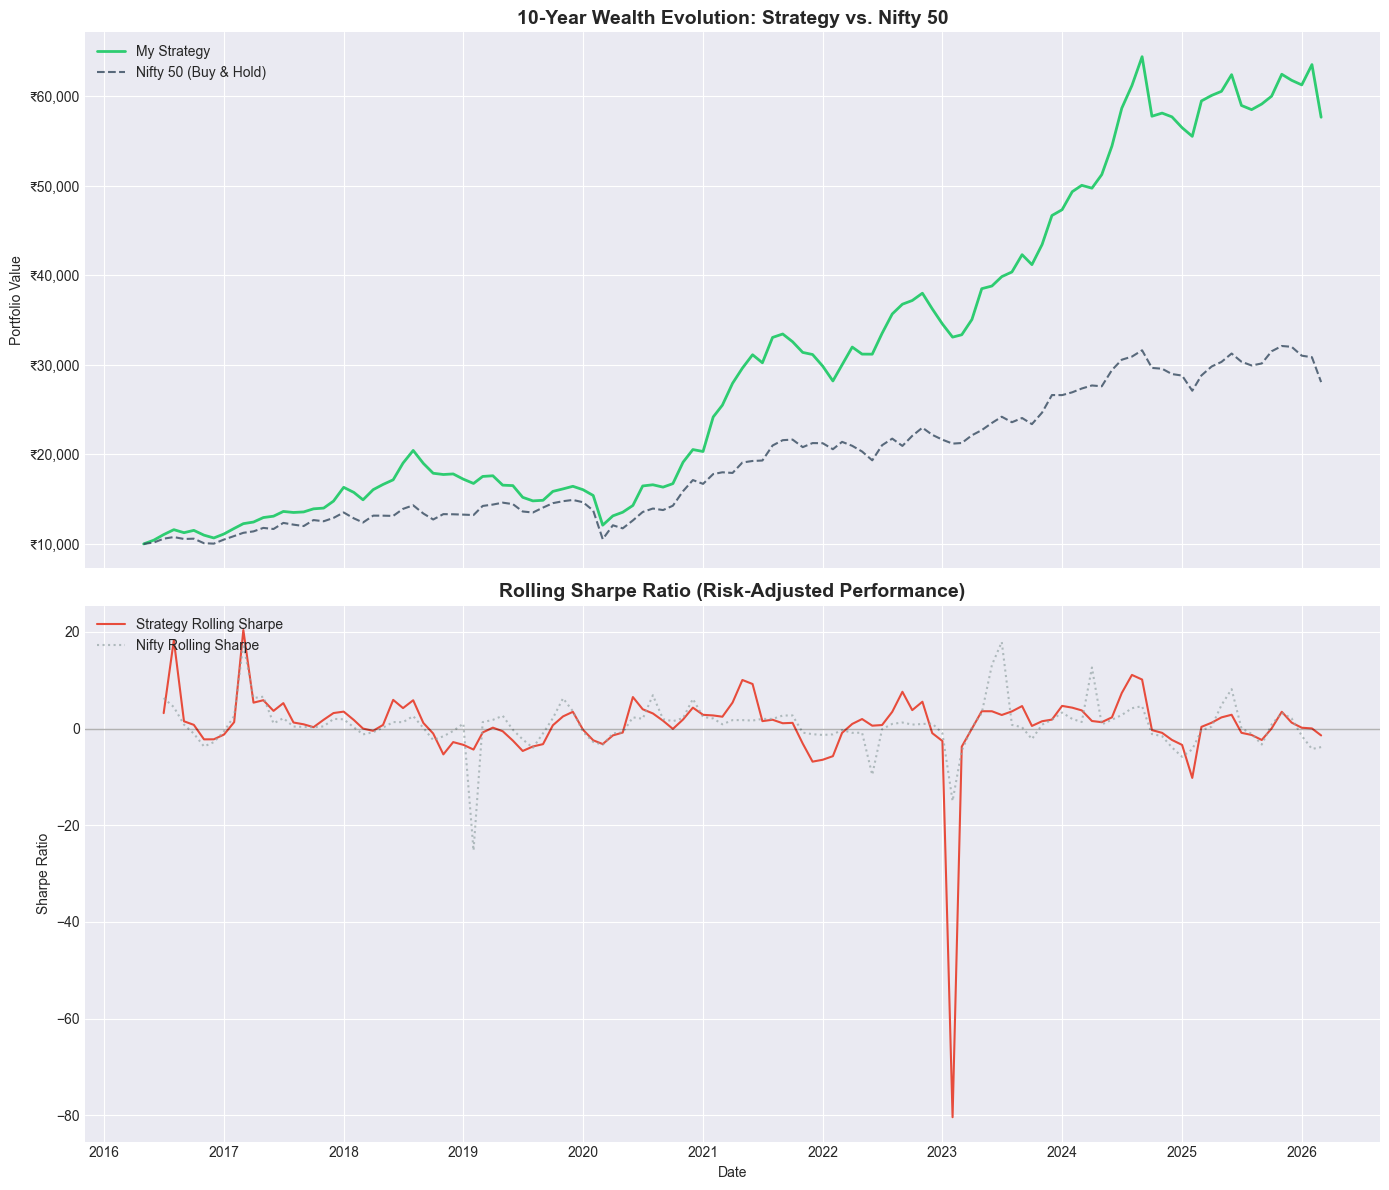

In [55]:
# --- 1. Data Alignment & Preparation ---
# Aligning portfolio returns with the original data index
portfolio_series = pd.Series(new_portfolio["mon_ret"].values, index=data.index[-len(new_portfolio):])

# Slicing Nifty data for a fair comparison
nifty_slice = data.iloc[-len(new_portfolio):].copy()
nifty_ret = nifty_slice['Close'].pct_change().fillna(0)

# Wealth Calculation (Cumulative Returns)
initial_investment = 10000
portfolio_value = (1 + portfolio_series).cumprod() * initial_investment
nifty_value = (1 + nifty_ret).cumprod() * initial_investment

port_rolling_sharpe = rolling_sharpe_df['rolling_sharpe']
nifty_rolling_sharpe = rol_sh['rolling_sharpe']

# --- 3. Plotting with Subplots ---
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# TOP PLOT: Wealth Evolution
ax1.plot(portfolio_value.index, portfolio_value, label='My Strategy', color='#2ecc71', linewidth=2)
ax1.plot(nifty_value.index, nifty_value, label='Nifty 50 (Buy & Hold)', color='#34495e', linestyle='--', alpha=0.8)
ax1.set_title('10-Year Wealth Evolution: Strategy vs. Nifty 50', fontsize=14, fontweight='bold')
ax1.set_ylabel('Portfolio Value')
ax1.yaxis.set_major_formatter(StrMethodFormatter('₹{x:,.0f}'))
ax1.legend(loc='upper left')

# BOTTOM PLOT: Rolling Sharpe Ratio
ax2.plot(portfolio_value.index, port_rolling_sharpe, label='Strategy Rolling Sharpe', color='#e74c3c', linewidth=1.5)
ax2.plot(nifty_value.index, nifty_rolling_sharpe[1:], label='Nifty Rolling Sharpe', color='#95a5a6', linestyle=':', alpha=0.7)
ax2.axhline(0, color='black', lw=1, alpha=0.3) # Zero line for reference
ax2.set_title('Rolling Sharpe Ratio (Risk-Adjusted Performance)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Sharpe Ratio')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
## Risk adjusted metrics

data['nifty_ret'] = data['Close'].pct_change().fillna(0)

beta, alpha, portfolio_ret, benchmark_ret, ann_port_ret, ann_bench_ret = jensens_alpha(new_portfolio['mon_ret'], data['nifty_ret'], 10)
rolling_alpha_df = rolling_alpha(new_portfolio['mon_ret'], data['nifty_ret'], 12, 3)

print(f"--- Risk-Adjusted Metrics ---")
print(f"Portfolio Beta:             {beta:.2f}")
print(f"Total Strategy Ret:         {portfolio_ret:.2%}")
print(f"Total Nifty Ret:            {benchmark_ret:.2%}")
print(f"Jensen's Alpha:             {alpha:.2%}")
print(f"Annualized Nifty Ret:       {ann_bench_ret:.2%}")
print(f"Annualized Portfolio Ret:   {ann_port_ret:.2%}")


NameError: name 'rolling_alpha_df' is not defined